In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import shutil
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams["font.family"] = "Arial"
plt.style.use("nature")


/pasteur/appa/scratch/dvu/github/SLIMshot/design_proteins/20251114_Melittin_Bombolitin/outputs/MB/20250430_4


In [14]:
#num of validation structures predicted by AF2 that pass ipTM
num_val = len(glob.glob(f"validation/*/*/*.pdb"))/2


#num of trajectories
num_traj = len(glob.glob(f"trajectories/*/*.csv"))

validation_file = "validation/SLIM_binder_from_PG_design.csv"
validation_df = pd.read_csv(validation_file)

num_val = len(validation_df)

mpnn_file = "mpnn/mpnn_redesigned_binders.csv"
mpnn_df = pd.read_csv(mpnn_file)

num_mpnn = len(mpnn_df)

design_file = 'final_binder_designs_stats.csv'
design_df = pd.read_csv(design_file)

num_design = len(design_df)

design_pipleine = [num_traj, num_val, num_mpnn, num_design]


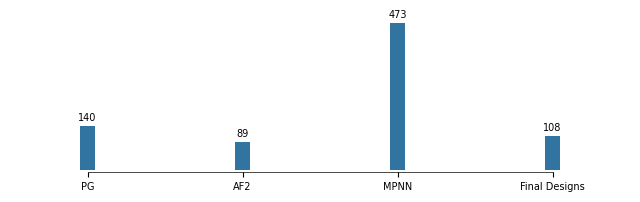

In [15]:
# Bar plot showing the number of items at each stage of the design pipeline
fig, ax = plt.subplots(figsize=(8, 2))
# Use seaborn barplot with appropriate width and color palette for accessibility
sns.barplot(x=list(range(len(design_pipleine))), y=design_pipleine, width=0.1, ax=ax)
# Annotate the values on top of each bar for clarity and accessibility
for i, value in enumerate(design_pipleine):
    ax.text(i, value + max(design_pipleine)*0.02, f"{int(value)}", ha='center', va='bottom', color='black')
# Optional: set x-tick labels for clarity
ax.set_xticks(range(len(design_pipleine)))
ax.set_xticklabels(['PG', 'AF2', 'MPNN', 'Final Designs'])
ax.set_xlabel('')
# Disable y-axis for clarity and accessibility
ax.get_yaxis().set_visible(False)
sns.despine(offset=2, trim=True, left=True)
fig_dir = "figs"
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
plt.savefig(os.path.join(fig_dir, "design_pipeline_bar_plot.pdf"), bbox_inches="tight")


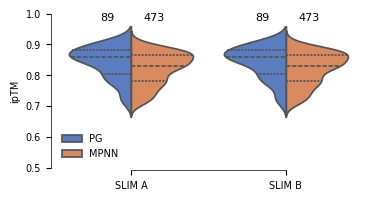

In [16]:
plot_df = pd.DataFrame({
    "ipTM": pd.concat([validation_df["SLIM_A_ipTM"], validation_df["SLIM_B_ipTM"],
                       mpnn_df["SLIM_A_ipTM"], mpnn_df["SLIM_B_ipTM"]], ignore_index=True),
    "Chain": (["SLIM_A"] * len(validation_df) + ["SLIM_B"] * len(validation_df) +
              ["SLIM_A"] * len(mpnn_df) + ["SLIM_B"] * len(mpnn_df)),
    "Design": (["PG"] * (2 * len(validation_df)) + ["MPNN"] * (2 * len(mpnn_df)))
})

fig, ax = plt.subplots(figsize=(4, 2))

# Split violin plot: x=Chain (SLIM_A/SLIM_B), hue=Design (PG/MPNN), split=True
sns.violinplot(
    data=plot_df, x="Chain", y="ipTM", hue="Design", ax=ax,
    inner="quartile", split=True, palette="muted"
)

# Add counts for each group above violins, offset for split
for i, chain in enumerate(["SLIM_A", "SLIM_B"]):
    for j, design in enumerate(["PG", "MPNN"]):
        count = plot_df[(plot_df["Chain"] == chain) & (plot_df["Design"] == design)].shape[0]
        # Offset text for each split side
        x_offset = i + (-0.15 if design == "PG" else 0.15)
        ax.text(x_offset, 0.97, str(count), ha='center', va='bottom', fontsize=8, color='black')

ax.set_ylabel("ipTM")
ax.set_xlabel("")
# ax.set_title("ipTM distribution for SLIM_A and SLIM_B by design method (split violin)")
ax.set_ylim(0.5, 1)
ax.set_xticklabels(["SLIM A", "SLIM B"])
ax.legend(title="", loc="lower left", frameon=False)
sns.despine(offset=2, trim=True)
fig_dir = "figs"
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
fig.savefig(os.path.join(fig_dir, "ipTM_distribution_SLIM_A_SLIM_B_by_design_method_split_violin.pdf"), bbox_inches="tight")
# Accessibility: Use clear color palette and readable font sizes for better accessibility.


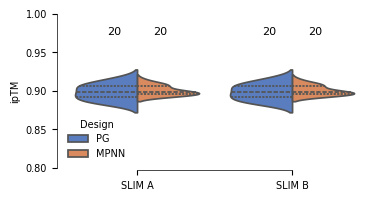

In [17]:
# Improved violin plot for ipTM values of SLIM_A and SLIM_B, grouped by design method (PG vs MPNN)
# This version separates SLIM_A and SLIM_B on the x-axis, and uses color for design method
# Prepare data for split violin plot: each row is a measurement, with columns for chain and design method
# Get top 20 by ipTM for each group (PG/MPNN, SLIM_A/SLIM_B)
# Select top 20 by average ipTM (mean of SLIM_A and SLIM_B) for each group, then split for plotting
def get_top_by_avg_iptm(df, design_label):
    df = df.copy()
    df["average_iptm"] = df[["SLIM_A_ipTM", "SLIM_B_ipTM"]].mean(axis=1)
    top = df.nlargest(20, "average_iptm")
    top_a = top[["SLIM_A_ipTM"]].assign(Chain="SLIM_A", Design=design_label)
    top_b = top[["SLIM_B_ipTM"]].assign(Chain="SLIM_B", Design=design_label)
    top_a = top_a.rename(columns={"SLIM_A_ipTM": "ipTM"})
    top_b = top_b.rename(columns={"SLIM_B_ipTM": "ipTM"})
    return top_a, top_b

top_pg_a, top_pg_b = get_top_by_avg_iptm(validation_df, "PG")
top_mpnn_a, top_mpnn_b = get_top_by_avg_iptm(mpnn_df, "MPNN")

# Concatenate all top 20s into one DataFrame for plotting
plot_df = pd.concat([top_pg_a, top_pg_b, top_mpnn_a, top_mpnn_b], ignore_index=True)

fig, ax = plt.subplots(figsize=(4, 2))

# Split violin plot: x=Chain (SLIM_A/SLIM_B), hue=Design (PG/MPNN), split=True
sns.violinplot(
    data=plot_df, x="Chain", y="ipTM", hue="Design", ax=ax,
    inner="quartile", split=True, palette="muted"
)

# Add counts for each group above violins, offset for split
for i, chain in enumerate(["SLIM_A", "SLIM_B"]):
    for j, design in enumerate(["PG", "MPNN"]):
        count = plot_df[(plot_df["Chain"] == chain) & (plot_df["Design"] == design)].shape[0]
        # Offset text for each split side
        x_offset = i + (-0.15 if design == "PG" else 0.15)
        ax.text(x_offset, 0.97, str(count), ha='center', va='bottom', fontsize=8, color='black')

ax.set_ylabel("ipTM")
ax.set_xlabel("")
ax.set_xticklabels(["SLIM A", "SLIM B"])
# ax.set_title("ipTM distribution for SLIM_A and SLIM_B by design method (split violin)")
ax.set_ylim(0.8, 1)
ax.legend(title="Design", loc="lower left", frameon=False)
sns.despine(offset=2, trim=True)
plt.savefig(os.path.join(fig_dir, "ipTM_distribution_SLIM_A_SLIM_B_by_design_method_split_violin_top20.pdf"), bbox_inches="tight")
# Accessibility: Use clear color palette and readable font sizes for better accessibility.


In [18]:
# Extract the columns with float values or int values
float_columns = design_df.select_dtypes(include=['float64', 'int64']).columns

columns_to_rename = {
    "ipTM_SLIM_A": "SLIM_A_ipTM", 
    "ipTM_SLIM_B": "SLIM_B_ipTM", 
    "rmsd_SLIM_A": "SLIM_A_rmsd", 
    "rmsd_SLIM_B": "SLIM_B_rmsd",
    "RMSD_complex_redesign_SLIM_A": "SLIM_A_RMSD_complex_redesign", 
    "RMSD_complex_redesign_SLIM_B": "SLIM_B_RMSD_complex_redesign"
}

# Rename the columns
design_df = design_df.rename(columns=columns_to_rename)
design_df

,id,seq,binder_ptm,SLIM_A_ipTM,SLIM_B_ipTM,SLIM_A_i_PAE,SLIM_B_i_PAE,SLIM_A_rmsd,SLIM_B_rmsd,SLIM_A_rmsd_before_after,...,SLIM_B_interface_fraction,SLIM_B_interface_hydrophobicity,SLIM_B_interface_nres,SLIM_B_interface_interface_hbonds,SLIM_B_interface_hbond_percentage,SLIM_B_interface_delta_unsat_hbonds,SLIM_B_interface_delta_unsat_hbonds_percentage,SLIM_B_interface_residues,SLIM_B_interface_AA,SLIM_B_num_clashes
0,2025114_MM_000001_mpnn3,SEEEIKKLKEEVKELLKKLKEIASKEDLSEDDLIEALEIAEKIFEL...,0.853,0.803,0.803,0.161,0.161,0.25,0.25,0.22,...,32.37,67.57,37,0,0.00,1.0,2.70,"B30,B31,B33,B34,B36,B37,B38,B40,B41,B43,B44,B4...","{'A': 4, 'C': 0, 'D': 1, 'E': 5, 'F': 3, 'G': ...",0
1,2025114_MM_000001_mpnn9,MSSKIKELKEKVEELLKKLEEIAEKEDLSEDDLIEALELAEEIFEL...,0.843,0.790,0.790,0.167,0.167,0.69,0.69,0.29,...,34.93,68.42,38,2,5.26,0.0,0.00,"B30,B31,B33,B34,B36,B37,B38,B40,B41,B42,B43,B4...","{'A': 5, 'C': 0, 'D': 1, 'E': 8, 'F': 3, 'G': ...",0
2,2025114_MM_000007_mpnn3,GKEEVKKKMKELLEELKELIEKVRKGELSLEELEERLKELYKKLEE...,0.820,0.804,0.804,0.145,0.145,1.94,1.94,0.34,...,39.84,65.96,47,3,6.38,3.0,6.38,"B5,B9,B16,B29,B30,B31,B33,B34,B35,B37,B38,B40,...","{'A': 6, 'C': 0, 'D': 1, 'E': 6, 'F': 1, 'G': ...",0
3,2025114_MM_000008_mpnn1,SHEELVEKLKQVLEELKELIEKLKKGELSVEEVIEELEKIKKLLVE...,0.732,0.866,0.866,0.121,0.121,2.13,2.13,0.26,...,41.56,61.22,49,4,8.16,3.0,6.12,"B5,B9,B12,B30,B31,B33,B34,B37,B38,B40,B41,B44,...","{'A': 4, 'C': 0, 'D': 0, 'E': 9, 'F': 0, 'G': ...",0
4,2025114_MM_000008_mpnn0,SHEELLETLEEVKEKLKELIKKLEEGELSVEEVIEELEEIKSLLVE...,0.867,0.864,0.864,0.123,0.123,0.35,0.35,0.25,...,39.88,64.58,48,2,4.17,2.0,4.17,"B5,B9,B12,B16,B30,B31,B33,B34,B37,B38,B40,B41,...","{'A': 5, 'C': 0, 'D': 0, 'E': 8, 'F': 0, 'G': ...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2025114_MM_000133_mpnn3,SAKEEYEKAMELIEEATKKIEKALKEGGSLDEIIEALEILKKGIDL...,0.840,0.847,0.847,0.126,0.126,2.22,2.22,0.28,...,40.06,68.18,44,2,4.55,0.0,0.00,"B29,B30,B31,B33,B34,B37,B38,B40,B41,B44,B45,B4...","{'A': 8, 'C': 0, 'D': 2, 'E': 6, 'F': 0, 'G': ...",0
104,2025114_MM_000134_mpnn1,GLEEIEKLLEETEKEIEELKKKIEEGKLSKEEFLEKLEEILKKIEE...,0.859,0.869,0.869,0.117,0.117,0.99,0.99,0.31,...,35.42,53.66,41,3,7.32,0.0,0.00,"B30,B31,B34,B35,B37,B38,B41,B42,B44,B45,B47,B4...","{'A': 5, 'C': 0, 'D': 0, 'E': 8, 'F': 0, 'G': ...",0
105,2025114_MM_000134_mpnn0,GQEKIKELLEKIKKEIEELEEKIRAGELSREEFLERLEEILKGIEE...,0.852,0.867,0.867,0.119,0.119,1.28,1.28,0.27,...,38.52,56.82,44,3,6.82,0.0,0.00,"B30,B31,B32,B34,B35,B37,B38,B41,B42,B44,B45,B4...","{'A': 7, 'C': 0, 'D': 0, 'E': 9, 'F': 0, 'G': ...",0
106,2025114_MM_000135_mpnn3,SMEEAKKLLEELLKKIEELIEKLKKGELSLEELVEEIEEIKKLLEK...,0.836,0.893,0.893,0.098,0.098,2.33,2.33,0.21,...,41.14,68.89,45,4,8.89,1.0,2.22,"B9,B12,B30,B31,B33,B34,B37,B38,B40,B41,B44,B45...","{'A': 4, 'C': 0, 'D': 1, 'E': 6, 'F': 1, 'G': ...",0


In [19]:
design_df.describe()

,binder_ptm,SLIM_A_ipTM,SLIM_B_ipTM,SLIM_A_i_PAE,SLIM_B_i_PAE,SLIM_A_rmsd,SLIM_B_rmsd,SLIM_A_rmsd_before_after,SLIM_B_rmsd_before_after,cycle,...,SLIM_B_interface_dSASA,SLIM_B_interface_dG_SASA_ratio,SLIM_B_interface_fraction,SLIM_B_interface_hydrophobicity,SLIM_B_interface_nres,SLIM_B_interface_interface_hbonds,SLIM_B_interface_hbond_percentage,SLIM_B_interface_delta_unsat_hbonds,SLIM_B_interface_delta_unsat_hbonds_percentage,SLIM_B_num_clashes
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,...,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.0
mean,0.821056,0.838361,0.838361,0.136546,0.136546,1.299630,1.299630,0.407130,0.407130,74.296296,...,2379.254352,-3.493056,38.868056,63.702130,42.416667,3.138889,7.418796,0.944444,2.154722,0.0
std,0.046708,0.046145,0.046145,0.028592,0.028592,0.890409,0.890409,0.211523,0.211523,38.172324,...,201.326672,0.289355,3.086904,4.990575,4.390144,1.456268,3.409240,0.955391,2.146483,0.0
min,0.701000,0.706000,0.706000,0.092000,0.092000,0.200000,0.200000,0.180000,0.180000,1.000000,...,1920.180000,-4.110000,32.240000,53.060000,33.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.779000,0.809250,0.809250,0.117000,0.117000,0.497500,0.497500,0.280000,0.280000,43.750000,...,2254.290000,-3.702500,36.545000,60.315000,39.000000,2.000000,4.970000,0.000000,0.000000,0.0
50%,0.836000,0.848000,0.848000,0.131500,0.131500,0.940000,0.940000,0.330000,0.330000,75.000000,...,2389.800000,-3.505000,39.260000,63.410000,42.000000,3.000000,7.320000,1.000000,2.245000,0.0
75%,0.858250,0.873000,0.873000,0.153000,0.153000,2.147500,2.147500,0.462500,0.462500,109.000000,...,2543.097500,-3.272500,41.047500,67.500000,46.000000,4.000000,9.580000,1.000000,2.902500,0.0
max,0.890000,0.914000,0.914000,0.219000,0.219000,3.210000,3.210000,1.180000,1.180000,135.000000,...,2809.970000,-2.700000,45.880000,74.470000,54.000000,7.000000,18.180000,3.000000,8.330000,0.0


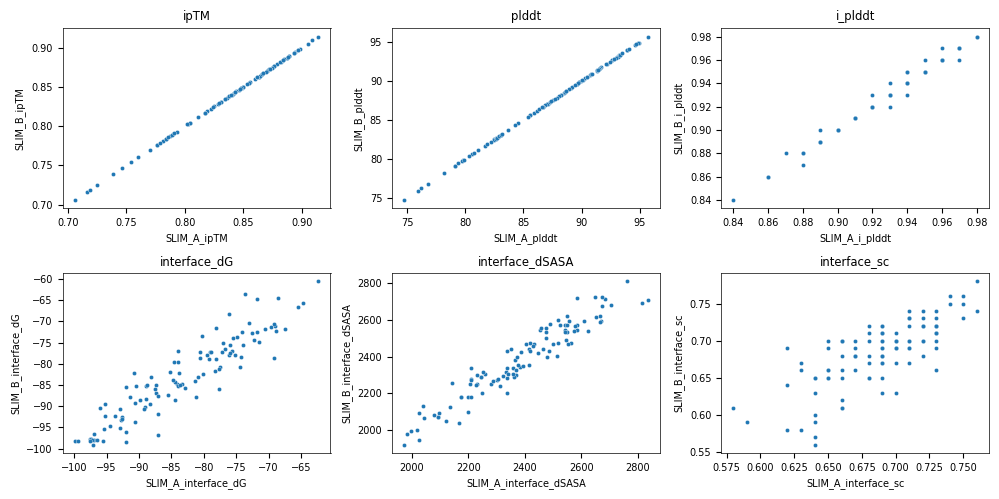

In [ ]:
AF2_params = ["ipTM", "plddt", "i_plddt"]
rosetta_params = ["interface_dG", "interface_dSASA", "interface_sc"]
params = AF2_params + rosetta_params

# Create subplots divided into two rows
ncols = len(params)//2 + len(params) % 2
fig, ax = plt.subplots(nrows=2, ncols=ncols, figsize=(10, 5))

# Iterate through parameters and create 1D distributions for SLIM_A
for i, param in enumerate(params):
    row = i // ncols  # Determine row index
    col = i % ncols   # Determine column index
    col_name = "SLIM_A_" + param
    if col_name in design_df.columns:
        sns.histplot(data=design_df, x=col_name, bins=30, kde=True, ax=ax[row, col], color="#4C72B0")
        ax[row, col].set_xlabel(param)
        ax[row, col].set_ylabel("Count")
    else:
        ax[row, col].text(0.5, 0.5, f"Missing: {col_name}", ha="center", va="center")
        ax[row, col].set_axis_off()
    ax[row, col].set_title(param)

plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


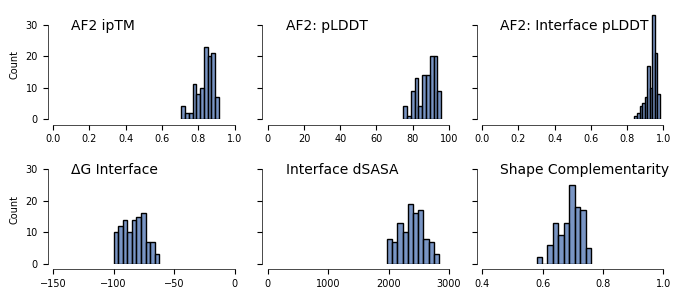

In [61]:
AF2_params = ["ipTM", "plddt", "i_plddt"]
rosetta_params = ["interface_dG", "interface_dSASA", "interface_sc"]
params = AF2_params + rosetta_params

ncols = len(params)//2 + len(params) % 2
fig, ax = plt.subplots(nrows=2, ncols=ncols, figsize=(7, 3), sharey=True)

subplot_titles = {
    "ipTM": "AF2 ipTM",
    "plddt": "AF2: pLDDT",
    "i_plddt": "AF2: Interface pLDDT",
    "interface_dG": "ΔG Interface",
    "interface_dSASA": "Interface dSASA",
    "interface_sc": "Shape Complementarity",
}

for i, param in enumerate(params):
    row = i // ncols
    col = i % ncols
    col_name = "SLIM_A_" + param
    if col_name in design_df.columns:
        hist = sns.histplot(data=design_df, x=col_name, bins=10, kde=False, ax=ax[row, col], color="#4C72B0")
        # Remove x-axis label for all subplots
        ax[row, col].set_xlabel("")
        ax[row, col].set_ylabel("Count")
        if param in ["ipTM", "i_plddt"]:
            ax[row, col].set_xlim(0, 1)
        elif param in ["plddt"]:
            ax[row, col].set_xlim(0, 100)
        elif param == "interface_dG":
            ax[row, col].set_xlim(-150, 0)
        elif param == "interface_dSASA":
            ax[row, col].set_xlim(0, 3000)
        elif param == "interface_sc":
            ax[row, col].set_xlim(0.4, 1)
        if param in ["ipTM", "plddt", "i_plddt", "interface_dG", "interface_dSASA", "interface_sc"]:
            ax[row, col].legend(frameon=False)
        # Put the title inside the subplot (use axes coordinates)
        ax[row, col].text(
            0.1, 0.92, subplot_titles.get(param, param),
            transform=ax[row, col].transAxes,
            fontsize=10,
            color="black",
            ha="left",
            va="top",
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
        )
    else:
        ax[row, col].text(0.5, 0.5, f"Missing: {col_name}", ha="center", va="center")
        ax[row, col].set_axis_off()
        # Still put the inside title even if missing
        ax[row, col].text(
            0.1, 0.92, subplot_titles.get(param, param),
            transform=ax[row, col].transAxes,
            fontsize=10,
            color="black",
            ha="left",
            va="top",
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
        )
    # Remove external title
    # ax[row, col].set_title(subplot_titles.get(param, param))
sns.despine(trim=True, offset=4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "distribution_of_paramter.pdf"))


In [21]:
design_df.sort_values(by="average_iptm", ascending=False, inplace=True, ignore_index=True)

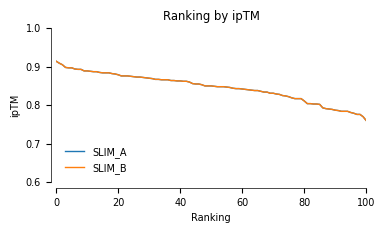

In [24]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.lineplot(data=design_df, x=design_df.index, y="SLIM_A_ipTM", ax=ax, label="SLIM_A")
sns.lineplot(data=design_df, x=design_df.index, y="SLIM_B_ipTM", ax=ax, label="SLIM_B")
ax.set_xlabel("Ranking")
ax.set_ylabel("ipTM")
ax.set_title("Ranking by ipTM")
ax.set_ylim(0.6, 1)
ax.set_xlim(0,100)
ax.legend(title="", loc="lower left", frameon=False)
sns.despine(offset=4, trim=True)
plt.savefig(os.path.join(fig_dir, "ranking_by_ipTM.pdf"), bbox_inches="tight")


In [23]:
top_dir, final_binder_dir = "top_binders", "final_binder_designs"
os.makedirs(top_dir, exist_ok=True)

# Efficiently copy top 15 binder PDBs for both SLIM_A and SLIM_B
for idx, row in design_df.head(15).iterrows():
    id_parts = row["id"].split("_")
    base = "_".join(id_parts[:4])
    suffix = "_".join(id_parts[4:6])
    for chain in ["A", "B"]:
        pdb_file = f"{base}_relaxed_SLIM_{chain}_{suffix}.pdb"
        shutil.copy(os.path.join(final_binder_dir, pdb_file), os.path.join(top_dir, pdb_file))


FileNotFoundError: [Errno 2] No such file or directory: 'final_binder_designs/2025114_MM_000068_mpnn6_relaxed_SLIM_A_.pdb'

In [ ]:
top_20_df = design_df.head(20)
top_20_df.to_csv("top_20_binders.csv", index=False)
